<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/01_data_preprocessing_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Preprocessing & EDA
### Customer Segmentation Clustering Project — Shared Setup

**Run this notebook in Google Colab.**

This notebook is the shared baseline for the whole project. It:
1. Loads the raw transaction-level e-commerce CSV
2. Cleans it and runs EDA
3. Aggregates it into a **customer-level RFM+ feature table** (one row per customer)
4. Builds and fits a `ColumnTransformer` (scaling + encoding)
5. Exports three artifacts that Notebooks 02, 03 and 04 all load as their shared starting point:
   - `data/customer_features_raw.csv` — customer-level table, **unscaled** (used later to build the final deployable pipeline)
   - `data/preprocessed_rfm_scaled.csv` — the scaled/encoded feature matrix (used directly by the clustering notebooks)
   - `models/preprocessor.joblib` — the fitted `ColumnTransformer` (used in Notebook 05 to assemble the final production pipeline)

> **Note on sources:** this project merges a `.md` step-by-step guide and a `.docx` architecture blueprint. Where they disagreed, the resolved choices are:
> - Notebook split: `01_data_preprocessing_eda` → `02_kmeans_clustering` → `03_hierarchical_clustering` → `04_dbscan_clustering` → `05_model_comparison_pipeline` (docx's structure)
> - Algorithms: **KMeans, Agglomerative/Hierarchical, DBSCAN** (md's guide) — GMM was dropped per your instruction
> - Feature engineering combines both: classic RFM (md) + log-transform and IQR outlier capping for skewed monetary/frequency features (docx)
> - Metrics: Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index — **not** Accuracy/F1/RMSE, since this is unsupervised clustering with no ground-truth labels (both source docs agree on this)

## 0. Setup

We mount Google Drive so that `data/`, `models/`, and `metrics/` persist and are shared across all 5 notebooks — each Colab notebook is a separate runtime with its own ephemeral disk, so Drive is what lets Notebook 02/03/04/05 pick up where this one left off.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = '/content/drive/MyDrive/customer-segmentation-ml'
for sub in ['data', 'models', 'metrics']:
    os.makedirs(f'{PROJECT_ROOT}/{sub}', exist_ok=True)

print('Project root:', PROJECT_ROOT)


Mounted at /content/drive
Project root: /content/drive/MyDrive/customer-segmentation-ml


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


## 1. Load raw data

Upload the raw CSV once — it will be copied into `data/` on Drive so you don't need to re-upload it for future runs of this notebook.

In [3]:
RAW_FILENAME = 'Raw_data.csv'  # change this if your file has a different name
raw_path_on_drive = f'{PROJECT_ROOT}/data/{RAW_FILENAME}'

if not os.path.exists(raw_path_on_drive):
    from google.colab import files
    print('Please upload the raw e-commerce CSV...')
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    os.rename(uploaded_name, raw_path_on_drive)

df = pd.read_csv(raw_path_on_drive)
print(df.shape)
df.head()

(250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


## 2. Data hygiene

- `Customer Age` and `Age` are identical in this dataset — drop the duplicate.
- `Customer Name` is constant per `Customer ID` and not predictive — drop it.
- Check for duplicate transaction rows, negative quantities, and non-positive prices (none are expected in this dataset, but we check defensively rather than assume).

In [5]:
assert (df['Age'] == df['Customer Age']).all(), 'Age and Customer Age differ - keep both if so'
df = df.drop(columns=['Customer Age', 'Customer Name'])

print('Duplicate rows:', df.duplicated().sum())
print('Negative/zero quantity rows:', (df['Quantity'] <= 0).sum())
print('Negative/zero price rows:', (df['Product Price'] <= 0).sum())
print('Negative/zero purchase amount rows:', (df['Total Purchase Amount'] <= 0).sum())

df = df.drop_duplicates()
df = df[(df['Quantity'] > 0) & (df['Product Price'] > 0) & (df['Total Purchase Amount'] > 0)]
print('Shape after hygiene checks:', df.shape)


Duplicate rows: 0
Negative/zero quantity rows: 0
Negative/zero price rows: 0
Negative/zero purchase amount rows: 0
Shape after hygiene checks: (250000, 11)


In [6]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
print('Date range:', df['Purchase Date'].min(), '->', df['Purchase Date'].max())


Date range: 2020-01-01 00:07:26 -> 2023-09-13 18:42:49


## 3. Missing values

Only `Returns` has missing values (~19% of rows). This is a binary flag (1 = returned, 0 = not returned), so median/mode imputation isn't meaningful the way it is for a continuous field — we impute missing `Returns` as **0**, i.e. assume a transaction with no return recorded was not returned. This is a defensible default and we call it out explicitly (an alternative would be imputing with the overall return rate; we note this as an assumption, not a certainty).

In [7]:
print(df.isnull().sum())
df['Returns'] = df['Returns'].fillna(0)


Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Returns                  47382
Age                          0
Gender                       0
Churn                        0
dtype: int64


## 4. EDA — transaction level

Distributions, outliers, correlations, and category breakdowns before we collapse to one row per customer.

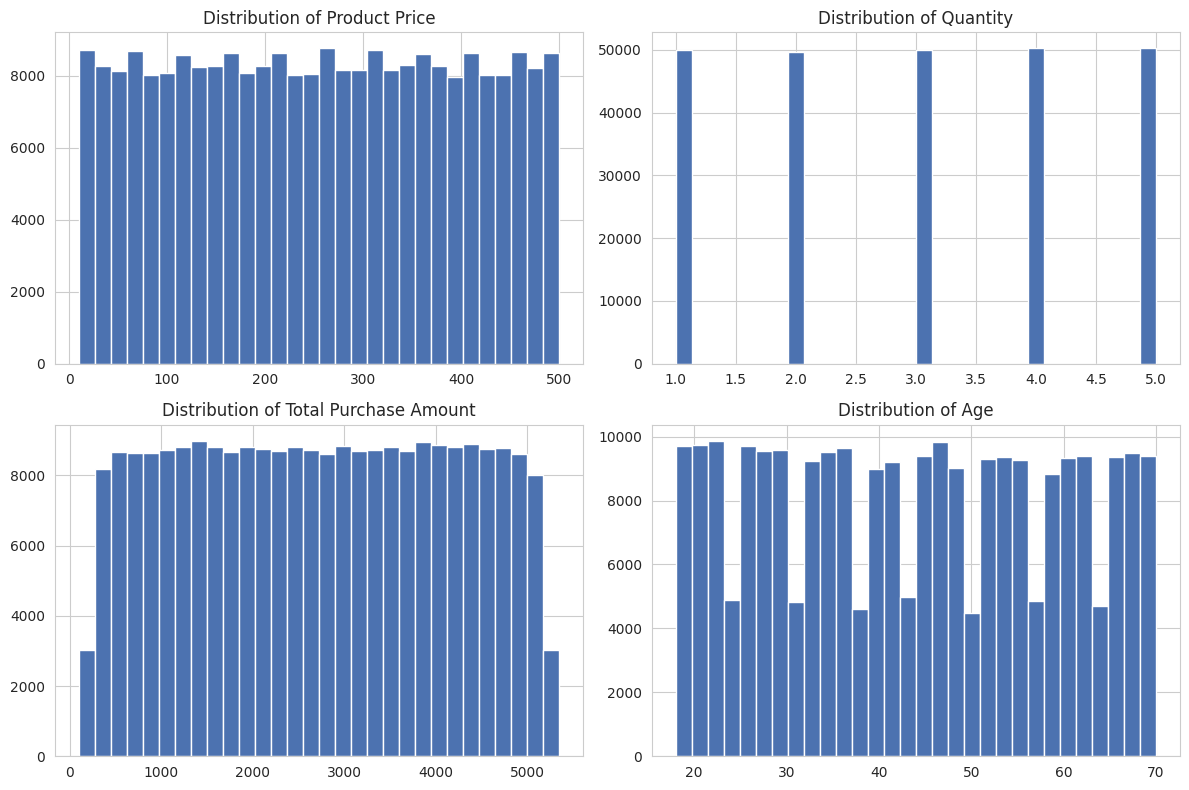

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ['Product Price', 'Quantity', 'Total Purchase Amount', 'Age']):
    ax.hist(df[col], bins=30, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


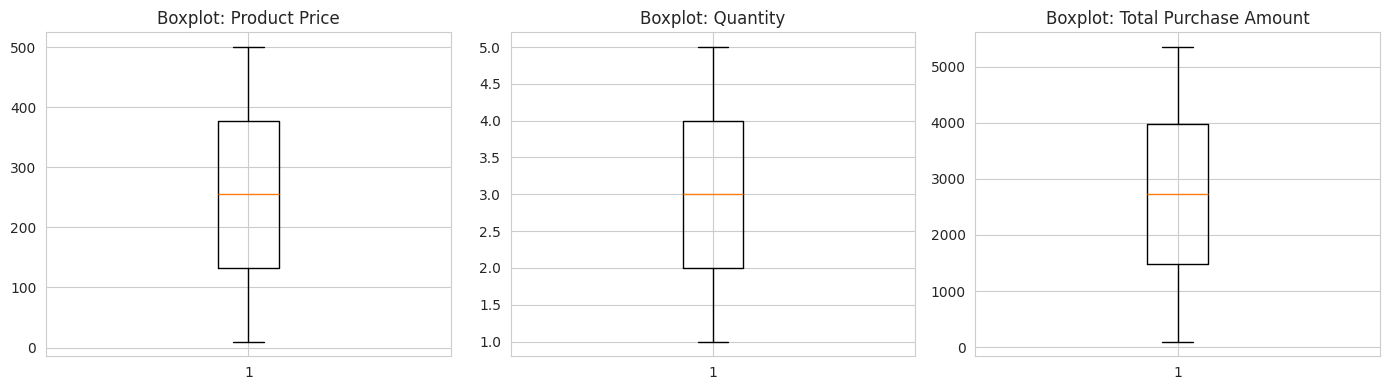

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Product Price', 'Quantity', 'Total Purchase Amount']):
    ax.boxplot(df[col])
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


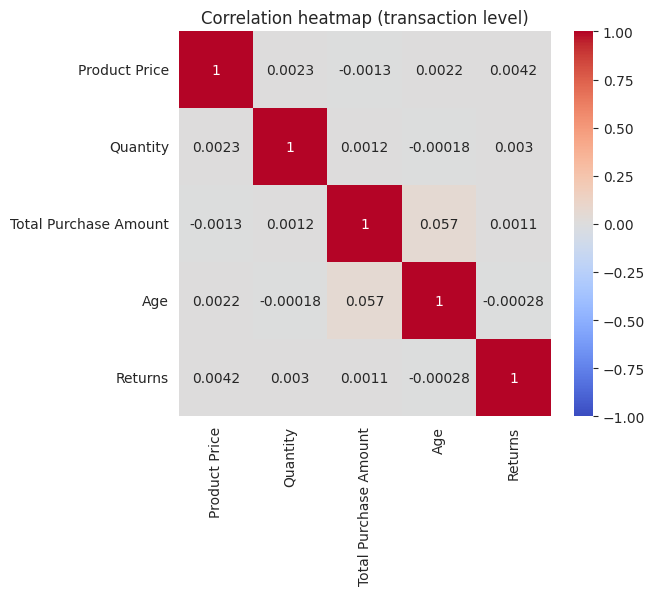

In [10]:
numeric_cols = ['Product Price', 'Quantity', 'Total Purchase Amount', 'Age', 'Returns']
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (transaction level)')
plt.show()


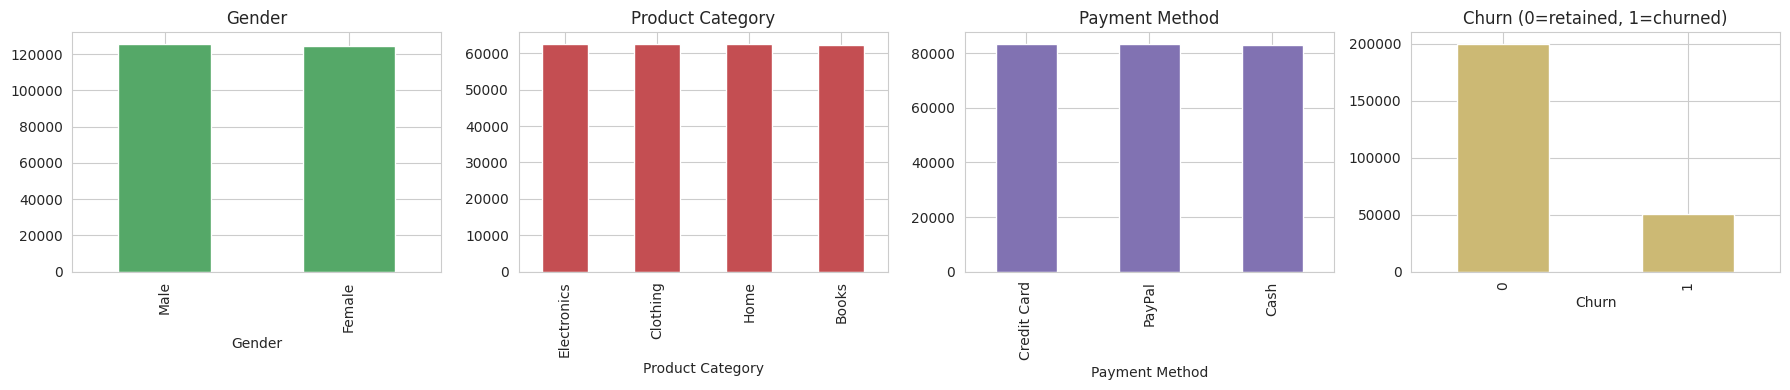

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
df['Gender'].value_counts().plot(kind='bar', ax=axes[0], title='Gender', color='#55A868')
df['Product Category'].value_counts().plot(kind='bar', ax=axes[1], title='Product Category', color='#C44E52')
df['Payment Method'].value_counts().plot(kind='bar', ax=axes[2], title='Payment Method', color='#8172B2')
df['Churn'].value_counts().plot(kind='bar', ax=axes[3], title='Churn (0=retained, 1=churned)', color='#CCB974')
plt.tight_layout()
plt.show()


## 5. Aggregate transactions → customers (RFM + extensions)

Clustering on the raw 250k transaction rows would group *purchases*, not *customers* — the wrong unit of analysis. We build one row per `Customer ID` with:

| Feature | Definition |
|---|---|
| `recency_days` | days since the customer's most recent purchase, relative to the latest date in the dataset |
| `frequency` | number of transactions |
| `monetary_total` | total amount spent |
| `monetary_avg` | average order value (AOV) = monetary_total / frequency |
| `avg_quantity` | average items per order |
| `return_rate` | % of the customer's orders that were returned |
| `age`, `gender` | constant per customer |
| `favorite_category`, `favorite_payment` | most frequent category / payment method |
| `churn` | kept **out** of the clustering features — used afterward only to sanity-check/profile clusters |

In [12]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('Customer ID').agg(
    recency_days=('Purchase Date', lambda x: (snapshot_date - x.max()).days),
    frequency=('Purchase Date', 'count'),
    monetary_total=('Total Purchase Amount', 'sum'),
    avg_quantity=('Quantity', 'mean'),
    return_rate=('Returns', 'mean'),
    age=('Age', 'first'),
    gender=('Gender', 'first'),
    churn=('Churn', 'first'),
).reset_index()

customer_df['monetary_avg'] = customer_df['monetary_total'] / customer_df['frequency']
customer_df['return_rate'] = customer_df['return_rate'] * 100  # percentage

customer_df['favorite_category'] = df.groupby('Customer ID')['Product Category'] \
    .agg(lambda x: x.mode()[0]).values
customer_df['favorite_payment'] = df.groupby('Customer ID')['Payment Method'] \
    .agg(lambda x: x.mode()[0]).values

print(customer_df.shape)
customer_df.head()


(49661, 12)


,Customer ID,recency_days,frequency,monetary_total,avg_quantity,return_rate,age,gender,churn,monetary_avg,favorite_category,favorite_payment
0,1,289,3,6290,5.00,0.000000,67,Female,0,2096.666667,Books,Credit Card
1,2,73,6,16481,3.00,66.666667,42,Female,0,2746.833333,Electronics,PayPal
2,3,223,4,9423,3.75,0.000000,31,Male,0,2355.750000,Electronics,Credit Card
3,4,442,5,7826,3.80,60.000000,37,Male,0,1565.200000,Books,Cash
4,5,425,5,9769,2.60,60.000000,24,Female,0,1953.800000,Home,Credit Card


## 6. EDA — customer level

Now we look at the distributions that actually feed the clustering algorithms.

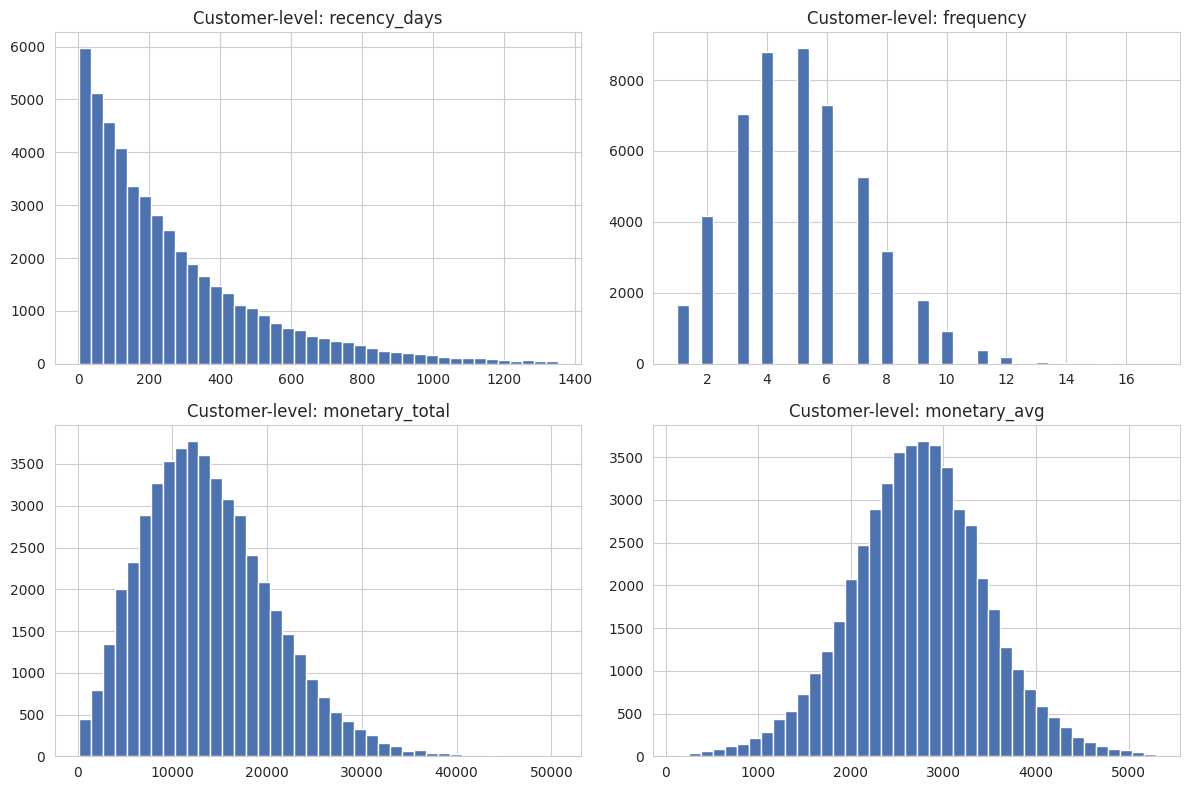

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ['recency_days', 'frequency', 'monetary_total', 'monetary_avg']):
    ax.hist(customer_df[col], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Customer-level: {col}')
plt.tight_layout()
plt.show()


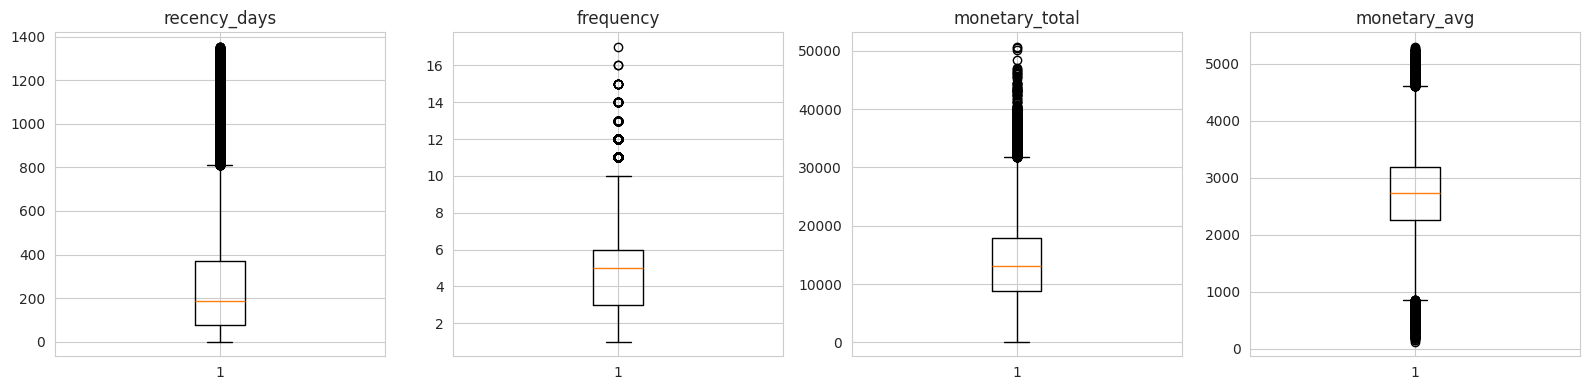

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['recency_days', 'frequency', 'monetary_total', 'monetary_avg']):
    ax.boxplot(customer_df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()


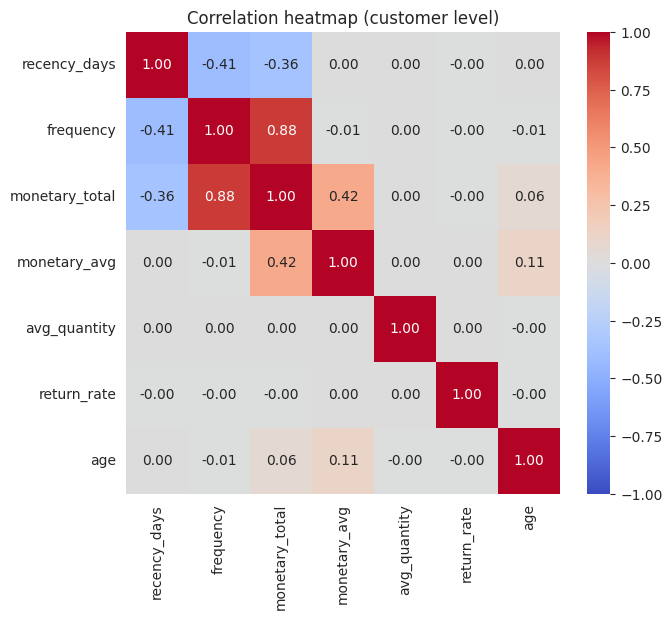

In [15]:
num_cols = ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'avg_quantity', 'return_rate', 'age']
plt.figure(figsize=(7, 6))
sns.heatmap(customer_df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (customer level)')
plt.show()


## 7. Outlier capping + skew correction

`frequency` and `monetary_total`/`monetary_avg` are right-skewed (a small number of very high-value/high-frequency customers). Distance-based clustering is sensitive to this, so we:

1. **Cap outliers** with the IQR rule (clip beyond `1.5 × IQR` from Q1/Q3) rather than drop them — we don't want to lose these customers, just stop them from dominating the distance metric. This is a training-time robustness step only (it uses quantiles computed from this dataset).
2. **Log-transform** (`log1p`) `frequency`/`monetary_total`/`monetary_avg` to pull in the right tail before scaling. Unlike capping, log1p is a pure per-row function with no dependency on dataset-wide statistics — which matters below, because it means we can safely bake it into the *production* pipeline, so a brand-new customer's raw numbers get log-transformed automatically at prediction time instead of requiring whoever calls the pipeline to pre-compute log columns themselves.

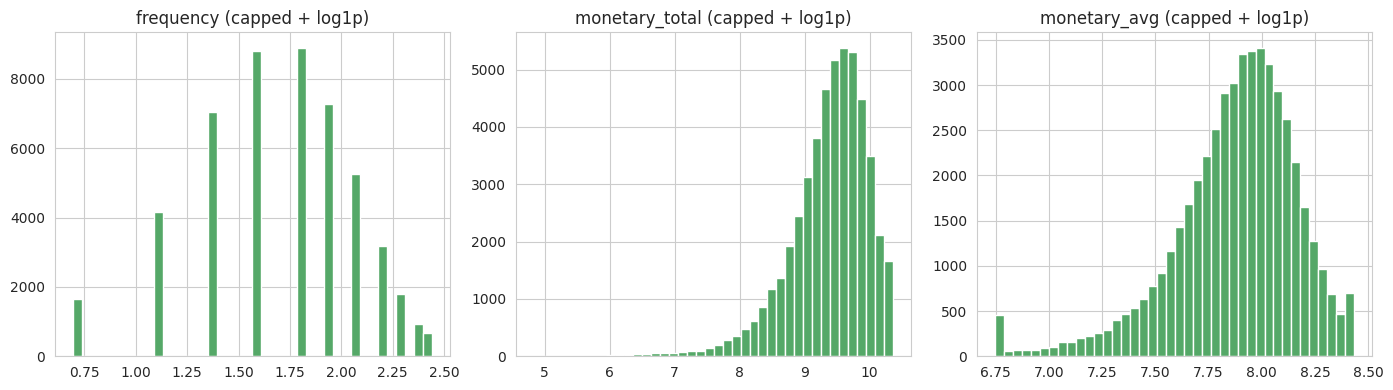

In [16]:
def iqr_cap(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower=lower, upper=upper)

skewed_cols = ['frequency', 'monetary_total', 'monetary_avg', 'avg_quantity']
for c in skewed_cols:
    customer_df[c] = iqr_cap(customer_df[c])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, ['frequency', 'monetary_total', 'monetary_avg']):
    ax.hist(np.log1p(customer_df[c]), bins=40, color='#55A868', edgecolor='white')
    ax.set_title(f'{c} (capped + log1p)')
plt.tight_layout()
plt.show()


## 8. Build the preprocessing pipeline

`StandardScaler` on numerics + `OneHotEncoder` on categoricals. This is mandatory for KMeans/DBSCAN/Hierarchical since they're all distance-based — unscaled `monetary_total` (hundreds/thousands) would dominate over `avg_quantity` (single digits) if left unscaled.

Rather than a single `ColumnTransformer`, we wrap the log1p step and the scaling/encoding step into one `Pipeline` object (`preprocessor`). That way the object we export in Section 9 accepts **raw** customer-level input — `frequency`, `monetary_total`, `monetary_avg` as real numbers, not pre-logged — which is exactly the shape of input a Gradio form (or any downstream caller) will naturally provide.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import numpy as np

# Log transform pipeline with feature name preservation
log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

# ColumnTransformer that matches your exact original column order (recency first)
column_transformer = ColumnTransformer([
    ('recency', StandardScaler(), ['recency_days']),
    ('log_num', log_pipeline, ['frequency', 'monetary_total', 'monetary_avg']),
    ('std_num', StandardScaler(), ['avg_quantity', 'return_rate', 'age']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['gender', 'favorite_category', 'favorite_payment']),
])

preprocessor = column_transformer

feature_cols = ['recency_days', 'frequency', 'monetary_total', 'monetary_avg',
                'avg_quantity', 'return_rate', 'age', 'gender', 'favorite_category', 'favorite_payment']

X = preprocessor.fit_transform(customer_df[feature_cols])

feature_names_out = column_transformer.get_feature_names_out()

print('Scaled feature matrix shape:', X.shape)
X_df = pd.DataFrame(X, columns=feature_names_out)
X_df.insert(0, 'Customer ID', customer_df['Customer ID'].values)
X_df.head()

Scaled feature matrix shape: (49661, 16)


,Customer ID,recency__recency_days,log_num__frequency,log_num__monetary_total,log_num__monetary_avg,std_num__avg_quantity,std_num__return_rate,std_num__age,cat__gender_Female,cat__gender_Male,cat__favorite_category_Books,cat__favorite_category_Clothing,cat__favorite_category_Electronics,cat__favorite_category_Home,cat__favorite_payment_Cash,cat__favorite_payment_Credit Card,cat__favorite_payment_PayPal
0,1,0.108041,-0.874740,-1.015684,-0.754214,2.786185,-1.637864,1.507722,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,-0.767155,0.570374,0.548134,0.159048,-0.006216,1.050733,-0.119278,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,3,-0.159380,-0.298509,-0.359502,-0.360282,1.040934,-1.637864,-0.835158,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,4,0.727971,0.172306,-0.660982,-1.742523,1.110744,0.781873,-0.444678,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,0.659089,0.172306,-0.300958,-0.992816,-0.564696,0.781873,-1.290718,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 9. Export artifacts

- `customer_features_raw.csv` — unscaled, human-readable, one row per customer (this is what a real Gradio/production input would look like)
- `preprocessed_rfm_scaled.csv` — the scaled + one-hot encoded matrix Notebooks 02–04 will load directly
- `preprocessor.joblib` — the fitted `ColumnTransformer`, reused in Notebook 05 to assemble the final end-to-end production pipeline

In [18]:
raw_export_cols = ['Customer ID', 'recency_days', 'frequency', 'monetary_total', 'monetary_avg',
                   'avg_quantity', 'return_rate', 'age', 'gender', 'favorite_category',
                   'favorite_payment', 'churn']
customer_df[raw_export_cols].to_csv(f'{PROJECT_ROOT}/data/customer_features_raw.csv', index=False)

X_df.to_csv(f'{PROJECT_ROOT}/data/preprocessed_rfm_scaled.csv', index=False)

joblib.dump(preprocessor, f'{PROJECT_ROOT}/models/preprocessor.joblib')
joblib.dump(feature_cols, f'{PROJECT_ROOT}/models/preprocessor_input_columns.joblib')

print('Exported:')
print(f' - {PROJECT_ROOT}/data/customer_features_raw.csv  ({customer_df.shape[0]} customers)')
print(f' - {PROJECT_ROOT}/data/preprocessed_rfm_scaled.csv  (shape {X_df.shape})')
print(f' - {PROJECT_ROOT}/models/preprocessor.joblib')


Exported:
 - /content/drive/MyDrive/customer-segmentation-ml/data/customer_features_raw.csv  (49661 customers)
 - /content/drive/MyDrive/customer-segmentation-ml/data/preprocessed_rfm_scaled.csv  (shape (49661, 17))
 - /content/drive/MyDrive/customer-segmentation-ml/models/preprocessor.joblib


## Done

Run **02_kmeans_clustering.ipynb**, **03_hierarchical_clustering.ipynb**, and **04_dbscan_clustering.ipynb** next — each mounts the same Drive folder and loads `data/preprocessed_rfm_scaled.csv` independently, so they can be run in any order or by different people. Then run **05_model_comparison_pipeline.ipynb** last to compare all three and build the deployable pipeline.